In [3]:
import os
import numpy as np
import pandas as pd
import time
import csv
import random
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split

import sklearn.metrics as metrics
from sklearn.metrics import roc_auc_score

use_gpu = torch.cuda.is_available()
print(use_gpu)

True


In [6]:
# Paths to the files with training, and validation sets.
# Each file contains pairs (path to image, output vector)
data_root = '/home/royhirsch/datasets/chexpert'

Traindata = pd.read_csv(os.path.join(data_root, 'CheXpert-v1.0/train.csv'))
Traindata = Traindata[Traindata['Path'].str.contains("frontal")] # use only frontal images
Traindata = Traindata[500:]
Traindata.to_csv(os.path.join(data_root, 'CheXpert-v1.0/train_mod.csv'), index = False)
print("Train data length:", len(Traindata))

Validdata = pd.read_csv(os.path.join(data_root, 'CheXpert-v1.0/valid.csv'))
Validdata = Validdata[Validdata['Path'].str.contains("frontal")] # use only frontal images
Validdata.to_csv(os.path.join(data_root, 'CheXpert-v1.0/valid_mod.csv'), index = False)
print("Valid data length:", len(Validdata))

Testdata = Traindata.head(500) # use first 500 training data as test data (obs ratio is almost same!)
Testdata.to_csv(os.path.join(data_root, 'CheXpert-v1.0/test_mod.csv'), index = False)
print("Test data length:", len(Testdata))

pathFileTrain = os.path.join(data_root, 'CheXpert-v1.0/train_mod.csv')
pathFileValid = os.path.join(data_root, 'CheXpert-v1.0/valid_mod.csv')
pathFileTest = os.path.join(data_root, 'CheXpert-v1.0/test_mod.csv')

# Neural network parameters:
nnIsTrained = False     # pre-trained using ImageNet
nnClassCount = 14       # dimension of the output

# Training settings: batch size, maximum number of epochs
trBatchSize = 16
trMaxEpoch = 3

# Parameters related to image transforms: size of the down-scaled image, cropped image
imgtransResize = (320, 320)
imgtransCrop = 224

# Class names
class_names = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
               'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 
               'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


Train data length: 190527
Valid data length: 202
Test data length: 500


In [34]:
class CheXpertDataSet(Dataset):
    def __init__(self, data_PATH, transform = None, policy = "zeros"):
        """
        data_PATH: path to the file containing images with corresponding labels.
        transform: optional transform to be applied on a sample.
        Upolicy: name the policy with regard to the uncertain labels.
        """
        image_names = []
        labels = []

        with open(data_PATH, "r") as f:
            csvReader = csv.reader(f)
            next(csvReader, None) # skip the header
            for line in csvReader:
                image_name = line[0]
                label = line[5:]
                
                for i in range(14):
                    if label[i]:
                        a = float(label[i])
                        if a == 1:
                            label[i] = 1
                        elif a == -1:
                            if policy == "ones":
                                label[i] = 1
                            elif policy == "zeroes":
                                label[i] = 0
                            else:
                                label[i] = 0
                        else:
                            label[i] = 0
                    else:
                        label[i] = 0
                        
                image_names.append(os.path.join(data_root, image_name))
                labels.append(label)

        self.image_names = image_names
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        """Take the index of item and returns the image and its labels"""
        image_name = self.image_names[index]
        image = Image.open(image_name).convert('RGB')
        label = self.labels[index]
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.FloatTensor(label)

    def __len__(self):
        return len(self.image_names)


In [35]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]  # mean of ImageNet dataset(for normalization)
IMAGENET_STD = [0.229, 0.224, 0.225]   # std of ImageNet dataset(for normalization)

# Tranform data
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
transformList = []

transformList.append(transforms.Resize((imgtransCrop, imgtransCrop))) # 224
# transformList.append(transforms.RandomResizedCrop(imgtransCrop))
# transformList.append(transforms.RandomHorizontalFlip())
transformList.append(transforms.ToTensor())
# transformList.append(normalize)
transformSequence = transforms.Compose(transformList)

# Load dataset
datasetTrain = CheXpertDataSet(pathFileTrain, transformSequence, policy = "zeros")
print("Train data length:", len(datasetTrain))

datasetValid = CheXpertDataSet(pathFileValid, transformSequence)
print("Valid data length:", len(datasetValid))

datasetTest = CheXpertDataSet(pathFileTest, transformSequence, policy = "zeros")
print("Test data length:", len(datasetTest))


Train data length: 190527
Valid data length: 202
Test data length: 500


In [12]:
s = datasetTrain.__getitem__(0)

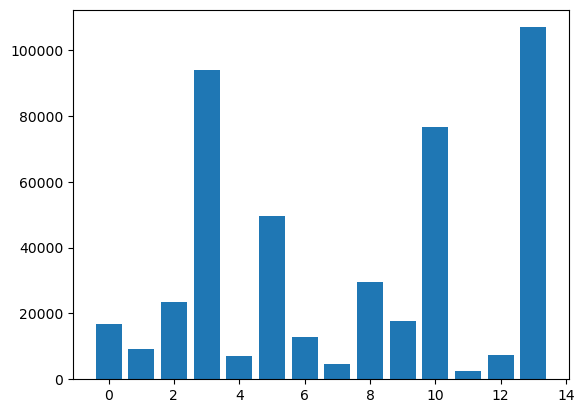

In [36]:
import matplotlib.pyplot as plt
_ = plt.bar(np.arange(14), np.stack(datasetTrain.labels).sum(0))

In [41]:
sum((np.stack(datasetTrain.labels).sum(1) == 0)), len(datasetTrain.labels)

(7746, 190527)

In [42]:
190527 - 7746

182781

In [44]:
(sum((np.stack(datasetTrain.labels).sum(1) == 1)),
sum((np.stack(datasetValid.labels).sum(1) == 1)),
sum((np.stack(datasetTest.labels).sum(1) == 1)))

(40274, 59, 121)

Text(0.5, 1.0, 'Number of labels histogram')

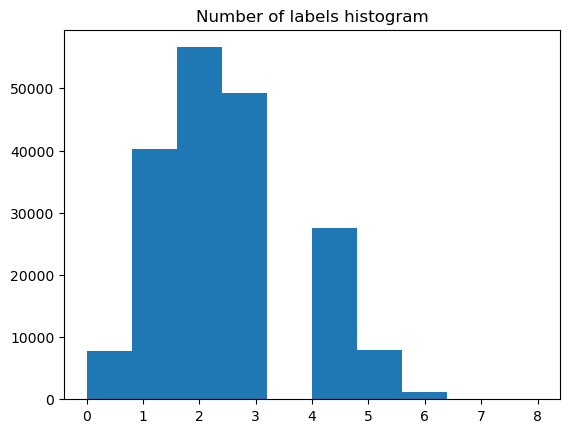

In [49]:
plt.hist(np.stack(datasetTrain.labels).sum(1))
plt.title('Number of labels histogram')